# Plotting with Pandas


## Table of Contents
1. [Importing Libraries  and Open NYC Tree Data](#Importing-Libraries-and-Open-Data)  
2. [Initial data check and cleaning](#Initialdata-check-and-cleaning)
3. [Single Variable Visualization](#Single-variable-visualization)
4. [Two or More Variables Visualization](#Two-or-more-variables-visualization)

## Importing-libraries-and-open-data
The first thing we do when creating visualizations is to import the necessary packages and read in the dataset we will be working with.

In [19]:
# Importing packages
import pandas as pd
import matplotlib.pyplot as plt


In [20]:
# Read NYC tree data. I downloaded the tree data, which can be read directly from the links below.
# The documents on each dataset are also available from my website.
# You can read 2015 tree census data using pd.read_csv 
tree2015 = pd.read_csv('../05/data/2015_Street_Tree_Census.csv')
tree2005 = pd.read_csv('../05/data/2005_Street_Tree_Census.csv')                       
tree1995 = pd.read_csv('../05/data/1995_Street_Tree_Census.csv')


C:\Users\Wenge\AppData\Local\Temp\ipykernel_21972\244534258.py:5: DtypeWarning: Columns (37) have mixed types. Specify dtype option on import or set low_memory=False.
  tree2005 = pd.read_csv('../05/data/2005_Street_Tree_Census.csv')


## Initialdata-check-and-cleaning

### Initial-data-checking

In [21]:
tree2015.head(10)
tree2015.tail(10)

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
683778,200671,229928,09/03/2015,29,0,OnCurb,Alive,Good,Platanus x acerifolia,London planetree,...,3053200,New York,40.624296,-73.960344,9.952583e+05,166726.7165,44.0,532.0,3180008.0,3.067170e+09
683779,193070,210437,08/31/2015,27,0,OnCurb,Alive,Good,Platanus x acerifolia,London planetree,...,3054800,New York,40.609541,-73.945835,9.992893e+05,161353.2295,48.0,548.0,3183517.0,3.068100e+09
683780,195173,304371,09/01/2015,15,0,OnCurb,Alive,Fair,Platanus x acerifolia,London planetree,...,4016900,New York,40.746122,-73.913657,1.008175e+06,211120.9420,26.0,169.0,4000947.0,4.001290e+09
683781,155348,230784,08/18/2015,20,0,OnCurb,Alive,Good,Quercus palustris,pin oak,...,3051001,New York,40.645694,-73.958179,9.958556e+05,174522.7192,40.0,51001.0,3328218.0,3.051250e+09
683782,184210,504308,08/29/2015,3,0,OnCurb,Alive,Good,Quercus palustris,pin oak,...,2038100,New York,40.854570,-73.899192,1.012137e+06,250636.4824,15.0,381.0,2013548.0,2.031490e+09
683783,155433,217978,08/18/2015,25,0,OnCurb,Alive,Good,Quercus palustris,pin oak,...,3051900,New York,40.713211,-73.954944,9.967407e+05,199121.6363,34.0,519.0,3062513.0,3.023690e+09
683784,183795,348185,08/29/2015,7,0,OnCurb,Alive,Good,Cladrastis kentukea,Kentucky yellowwood,...,4070700,New York,40.715194,-73.856650,1.023989e+06,199873.6475,29.0,707.0,4075448.0,4.031810e+09
683785,166161,401670,08/22/2015,12,0,OnCurb,Alive,Good,Acer rubrum,red maple,...,5020100,New York,40.620762,-74.136517,9.463514e+05,165466.0763,50.0,201.0,5011657.0,5.004080e+09
683786,184028,504204,08/29/2015,9,0,OnCurb,Alive,Good,Acer rubrum,red maple,...,2023502,New York,40.850828,-73.903115,1.011054e+06,249271.9507,15.0,23502.0,2007757.0,2.028120e+09
683787,200607,306527,09/03/2015,23,0,OnCurb,Alive,Fair,Acer rubrum,red maple,...,4134100,New York,40.732165,-73.787526,1.043136e+06,206095.5383,24.0,1341.0,4153657.0,4.071360e+09


In [4]:
tree2015.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683788 entries, 0 to 683787
Data columns (total 45 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   tree_id           683788 non-null  int64  
 1   block_id          683788 non-null  int64  
 2   created_at        683788 non-null  object 
 3   tree_dbh          683788 non-null  int64  
 4   stump_diam        683788 non-null  int64  
 5   curb_loc          683788 non-null  object 
 6   status            683788 non-null  object 
 7   health            652172 non-null  object 
 8   spc_latin         652169 non-null  object 
 9   spc_common        652169 non-null  object 
 10  steward           164350 non-null  object 
 11  guards            79866 non-null   object 
 12  sidewalk          652172 non-null  object 
 13  user_type         683788 non-null  object 
 14  problems          225844 non-null  object 
 15  root_stone        683788 non-null  object 
 16  root_grate        68

In [22]:
# check the index 
tree2015.index

RangeIndex(start=0, stop=683788, step=1)

In [23]:
#check the columns
tree2015.columns

Index(['tree_id', 'block_id', 'created_at', 'tree_dbh', 'stump_diam',
       'curb_loc', 'status', 'health', 'spc_latin', 'spc_common', 'steward',
       'guards', 'sidewalk', 'user_type', 'problems', 'root_stone',
       'root_grate', 'root_other', 'trunk_wire', 'trnk_light', 'trnk_other',
       'brch_light', 'brch_shoe', 'brch_other', 'address', 'postcode',
       'zip_city', 'community board', 'borocode', 'borough', 'cncldist',
       'st_assem', 'st_senate', 'nta', 'nta_name', 'boro_ct', 'state',
       'latitude', 'longitude', 'x_sp', 'y_sp', 'council district',
       'census tract', 'bin', 'bbl'],
      dtype='object')

In [ ]:
tree1995.columns

In [24]:
tree2015.shape

(683788, 45)

In [ ]:
### Select subsets <a id=2.2></a>

In [25]:
tree2015['borough']

0                Queens
1                Queens
2              Brooklyn
3              Brooklyn
4              Brooklyn
              ...      
683783         Brooklyn
683784           Queens
683785    Staten Island
683786            Bronx
683787           Queens
Name: borough, Length: 683788, dtype: object

In [26]:
tree2015.loc[0:4]

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
0,180683,348711,08/27/2015,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,...,4073900,New York,40.723092,-73.844215,1027431.148,202756.7687,29.0,739.0,4052307.0,4.022210e+09
1,200540,315986,09/03/2015,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,...,4097300,New York,40.794111,-73.818679,1034455.701,228644.8374,19.0,973.0,4101931.0,4.044750e+09
2,204026,218365,09/05/2015,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,3044900,New York,40.717581,-73.936608,1001822.831,200716.8913,34.0,449.0,3338310.0,3.028870e+09
3,204337,217969,09/05/2015,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,3044900,New York,40.713537,-73.934456,1002420.358,199244.2531,34.0,449.0,3338342.0,3.029250e+09
4,189565,223043,08/30/2015,21,0,OnCurb,Alive,Good,Tilia americana,American linden,...,3016500,New York,40.666778,-73.975979,990913.775,182202.4260,39.0,165.0,3025654.0,3.010850e+09


In [27]:
tree2015.iloc[0:4]

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
0,180683,348711,08/27/2015,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,...,4073900,New York,40.723092,-73.844215,1027431.148,202756.7687,29.0,739.0,4052307.0,4.022210e+09
1,200540,315986,09/03/2015,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,...,4097300,New York,40.794111,-73.818679,1034455.701,228644.8374,19.0,973.0,4101931.0,4.044750e+09
2,204026,218365,09/05/2015,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,3044900,New York,40.717581,-73.936608,1001822.831,200716.8913,34.0,449.0,3338310.0,3.028870e+09
3,204337,217969,09/05/2015,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,3044900,New York,40.713537,-73.934456,1002420.358,199244.2531,34.0,449.0,3338342.0,3.029250e+09


In [28]:
# Two ways to print selected columns and indices
#tree2015.loc[0:4].borough]
tree2015.loc[0:4,'borough']

0      Queens
1      Queens
2    Brooklyn
3    Brooklyn
4    Brooklyn
Name: borough, dtype: object

In [29]:
# Extract information for certain columns
tree2015[['tree_id', 'tree_dbh','spc_common','borough']]

,tree_id,tree_dbh,spc_common,borough
0,180683,3,red maple,Queens
1,200540,21,pin oak,Queens
2,204026,3,honeylocust,Brooklyn
3,204337,10,honeylocust,Brooklyn
4,189565,21,American linden,Brooklyn
...,...,...,...,...
683783,155433,25,pin oak,Brooklyn
683784,183795,7,Kentucky yellowwood,Queens
683785,166161,12,red maple,Staten Island
683786,184028,9,red maple,Bronx


In [30]:
# check tree dbh > 50 in 
tree2015[tree2015['tree_dbh'] > 50]['borough']
#tree2015[tree2015['tree_dbh'] > 50].borough

2405           Brooklyn
3738             Queens
4887      Staten Island
6724      Staten Island
10083             Bronx
              ...      
675265           Queens
677954           Queens
679894           Queens
681736           Queens
682788            Bronx
Name: borough, Length: 364, dtype: object

In [31]:
tree2015[tree2015['tree_dbh'] > 50].spc_common
#tree2015[tree2015['tree_dbh'] > 50].size
#tree2015[tree2015['tree_dbh'] > 50].count()

2405      swamp white oak
3738         silver maple
4887         silver maple
6724              pin oak
10083         honeylocust
               ...       
675265            pin oak
677954       silver maple
679894          white oak
681736            pin oak
682788                NaN
Name: spc_common, Length: 364, dtype: object

In [32]:
#the isin() conditional function returns a True for each row the values are in the provided list.
#To filter the rows based on such a function, use the conditional function inside the selection brackets [].
# find which trees in Mahanttan. 
#tree2015[tree2015['borough'].isin(['Manhattan'])].count()
tree2015[tree2015['borough'] == 'Manhattan'].count()
tree2015[ (tree2015['borough'] == 'Manhattan') & (tree2015['tree_dbh'] > 50) ]

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
100308,304388,109033,10/10/2015,228,0,OnCurb,Alive,Fair,Pyrus calleryana,Callery pear,...,1019000,New York,40.802178,-73.948116,9.986145e+05,231536.3549,9.0,190.0,1051434.0,1.016010e+09
100348,277770,100613,10/02/2015,88,0,OnCurb,Alive,Good,Pyrus calleryana,Callery pear,...,1031703,New York,40.717307,-74.013326,9.805560e+05,200611.2196,1.0,31703.0,1085459.0,1.000160e+09
104376,312545,110893,10/12/2015,120,0,OnCurb,Alive,Good,Quercus phellos,willow oak,...,1025300,New York,40.843756,-73.937922,1.001426e+06,246686.6182,10.0,253.0,1063468.0,1.021410e+09
106182,296329,107426,10/08/2015,74,0,OnCurb,Alive,Good,Ginkgo biloba,ginkgo,...,1012000,New York,40.768142,-73.962694,9.945836e+05,219133.6559,4.0,120.0,1042493.0,1.014040e+09
131451,312202,108838,10/12/2015,109,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,1023501,New York,40.830994,-73.943261,9.999516e+05,242035.9796,7.0,23501.0,1061681.0,1.020680e+09
270493,476317,602575,11/20/2015,318,0,OnCurb,Alive,Good,Quercus palustris,pin oak,...,1027500,New York,40.850879,-73.943067,1.000001e+06,249280.8739,10.0,265.0,1064326.0,1.021770e+09
304556,523306,602362,12/16/2015,54,0,OffsetFromCurb,Alive,Good,Tilia tomentosa,silver linden,...,1018700,New York,40.799399,-73.973228,9.916623e+05,230520.6148,6.0,187.0,1057147.0,1.018890e+09
309449,523465,602362,12/16/2015,52,0,OffsetFromCurb,Alive,Good,Ulmus americana,American elm,...,1019900,New York,40.805824,-73.968232,9.930446e+05,232862.2076,NaN,NaN,NaN,NaN
655873,151093,110720,08/16/2015,62,0,OffsetFromCurb,Alive,Good,Ulmus americana,American elm,...,1024301,New York,40.837050,-73.939971,1.000861e+06,244242.9338,7.0,24301.0,1062892.0,1.021210e+09
660328,176434,105392,08/26/2015,199,0,OnCurb,Alive,Good,Quercus phellos,willow oak,...,1006400,New York,40.738028,-73.981496,9.893780e+05,208160.4640,2.0,64.0,1019657.0,1.009030e+09


In [33]:
# Select specific rows  and columns
tree2015.loc[tree2015['tree_dbh'] > 50, 'spc_common']
tree2015.loc[0:4, 'spc_common']


0          red maple
1            pin oak
2        honeylocust
3        honeylocust
4    American linden
Name: spc_common, dtype: object

In [34]:
# update the column value
#tree2015[tree2015.borocode ==5].borough
#tree2005[tree2005.borocode == 5].boroname
tree2005.loc[tree2005.borocode == 5, 'boroname'] = 'Staten Island'
tree2005[tree2005.borocode == 5].boroname

429490    Staten Island
429508    Staten Island
429574    Staten Island
429676    Staten Island
429872    Staten Island
              ...      
592367    Staten Island
592368    Staten Island
592369    Staten Island
592370    Staten Island
592371    Staten Island
Name: boroname, Length: 99701, dtype: object

## Single-variable-visualization

There are two types of variables we can visualize: **categorical** and **numerical** variables. 


**Categorical** variables are not numbers. They are variables such as specise name, borough name.  Numbers can also be encoded as categorical variables such as zipcode ("11360","11428","90210").

**Numerical** variables are numbers. They are variables such as tree dbh values 


### Categorical Variables <a id=3.1></a>

In [35]:
# Number of tree counts by species 
# treecounts = tree2015.groupby('spc_common').size()
tree2015.groupby('borough').size()

borough
Bronx             85203
Brooklyn         177293
Manhattan         65423
Queens           250551
Staten Island    105318
dtype: int64

In [37]:
tree2015.groupby('borough').count()

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
borough,,,,,,,,,,,,,,,,,,,,,
Bronx,85203,85203,85203,85203,85203,85203,85203,80585,80584,80584,...,85203,85203,85203,85203,85203,85203,84266,84266,83825,83825
Brooklyn,177293,177293,177293,177293,177293,177293,177293,169744,169744,169744,...,177293,177293,177293,177293,177293,177293,176788,176788,176191,176191
Manhattan,65423,65423,65423,65423,65423,65423,65423,62427,62428,62428,...,65423,65423,65423,65423,65423,65423,63616,63616,63301,63301
Queens,250551,250551,250551,250551,250551,250551,250551,237974,237970,237970,...,250551,250551,250551,250551,250551,250551,247923,247923,246777,246777
Staten Island,105318,105318,105318,105318,105318,105318,105318,101442,101443,101443,...,105318,105318,105318,105318,105318,105318,104676,104676,104135,104135


In [9]:
# Number of tree counts by species 
# treecounts = tree2015.groupby('spc_common').size()
#tree2015.groupby('borough').size()

tree2015.groupby('borough').count()

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
borough,,,,,,,,,,,,,,,,,,,,,
Bronx,85203,85203,85203,85203,85203,85203,85203,80585,80584,80584,...,85203,85203,85203,85203,85203,85203,84266,84266,83825,83825
Brooklyn,177293,177293,177293,177293,177293,177293,177293,169744,169744,169744,...,177293,177293,177293,177293,177293,177293,176788,176788,176191,176191
Manhattan,65423,65423,65423,65423,65423,65423,65423,62427,62428,62428,...,65423,65423,65423,65423,65423,65423,63616,63616,63301,63301
Queens,250551,250551,250551,250551,250551,250551,250551,237974,237970,237970,...,250551,250551,250551,250551,250551,250551,247923,247923,246777,246777
Staten Island,105318,105318,105318,105318,105318,105318,105318,101442,101443,101443,...,105318,105318,105318,105318,105318,105318,104676,104676,104135,104135


Pandas plotting functions:
- df.plot.area     
- df.plot.barh     
- df.plot.density  
- df.plot.hist     
- df.plot.line     
- df.plot.scatter
- df.plot.bar      
- df.plot.box      
- df.plot.hexbin   
- df.plot.kde      
- df.plot.pie

https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html#visualization


<class 'pandas.core.series.Series'>


Text(0, 0.5, 'Tree Count')

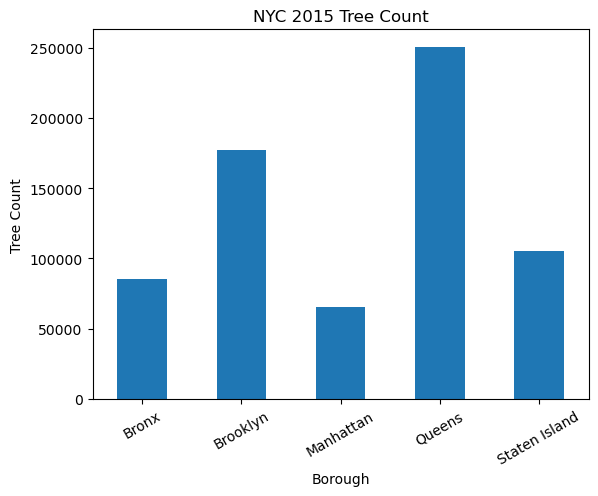

In [38]:
#plot a bar chart
#tree2015.groupby('borough').size().plot.bar(title = 'NYC 2015 Tree Count')
treecount_2015 = tree2015.groupby('borough').size()
print(type(treecount_2015))
treecount_2015.plot.bar(title = 'NYC 2015 Tree Count')
#treecount_2015.plot.barh(title = 'NYC 2015 Tree Count')
plt.xticks(rotation = 30, horizontalalignment = 'center') 
plt.xlabel('Borough')
plt.ylabel('Tree Count')


In [39]:
# create a df to include all tree counts
treecount = pd.DataFrame({
    '2015': tree2015.groupby('borough').size(),
    '2005': tree2005.groupby('boroname').size()}
)
treecount

,2015,2005
Bronx,85203,59925
Brooklyn,177293,142852
Manhattan,65423,49886
Queens,250551,240008
Staten Island,105318,99701


Text(0, 0.5, 'Tree Count')

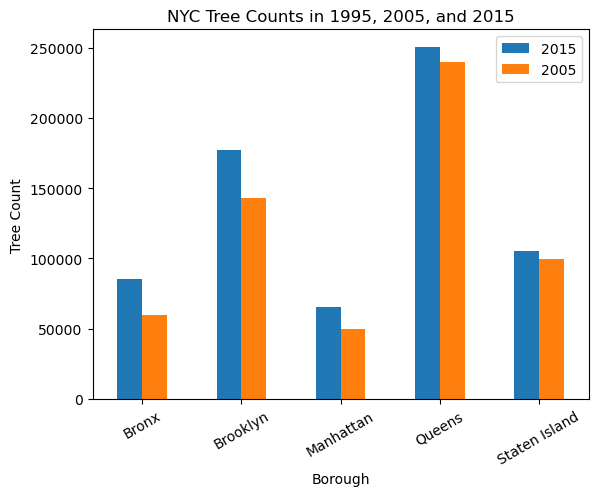

In [40]:
treecount.plot(kind = 'bar')
plt.xticks(rotation = 30, horizontalalignment = 'center')
plt.title('NYC Tree Counts in 1995, 2005, and 2015')
plt.xlabel('Borough')
plt.ylabel('Tree Count')

Text(0, 0.5, 'Tree Count')

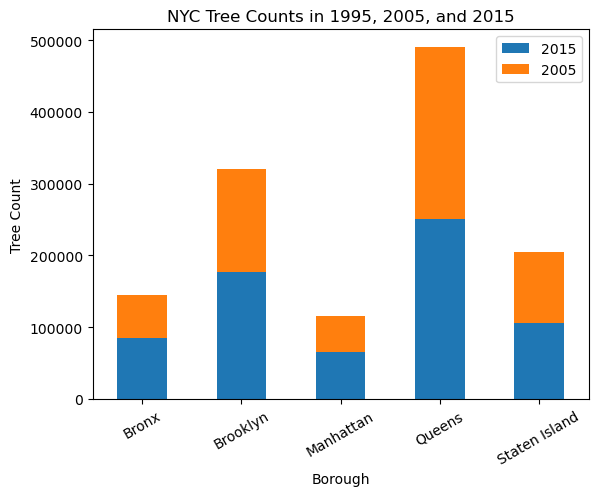

In [45]:
treecount.plot(kind = 'bar', stacked = True)
plt.xticks(rotation = 30, horizontalalignment = 'center')
plt.title('NYC Tree Counts in 1995, 2005, and 2015')
plt.xlabel('Borough')
plt.ylabel('Tree Count')


Text(0, 0.5, 'Tree Count')

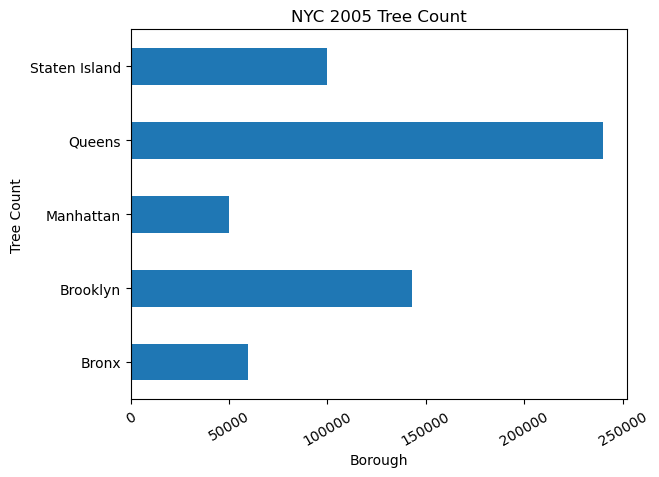

In [43]:
# horizontal bar 
tree2005.groupby('boroname').size().plot(kind = 'barh', title = 'NYC 2005 Tree Count')
#tree2005.groupby('boroname').size().plot.barh(title = 'NYC 2005 Tree Count')
plt.xticks(rotation = 30, horizontalalignment = 'center') 
plt.xlabel('Borough')
plt.ylabel('Tree Count')

### pie Graphs<a id=3.1.2></a>

array([<Axes: ylabel='2015'>, <Axes: ylabel='2005'>], dtype=object)

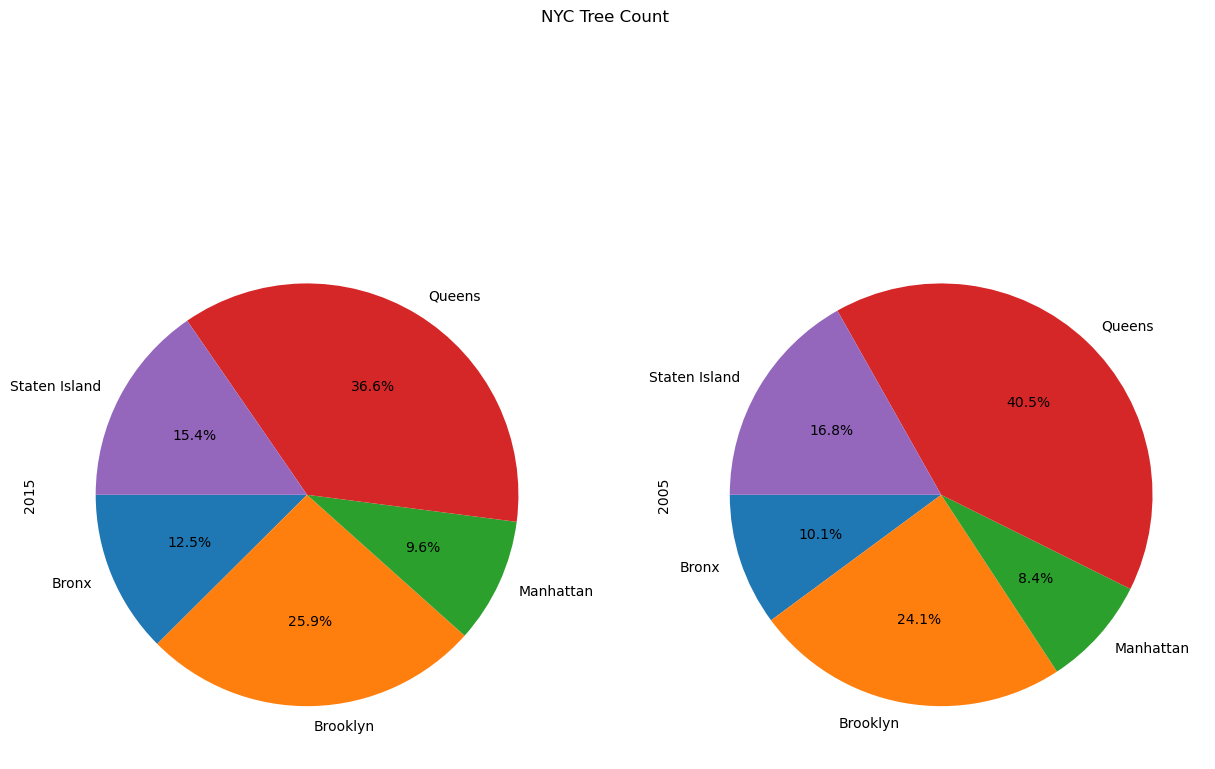

In [46]:
treecount.plot.pie(title = 'NYC Tree Count', legend=False, startangle=180,  autopct='%1.1f%%', subplots=True, figsize=(15,10))

<Axes: title={'center': 'NYC 2015 Tree Count'}>

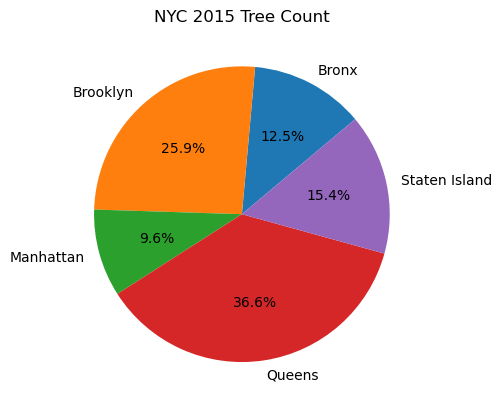

In [13]:
# pie chart
treecount2015 = tree2015.groupby('borough').size()
#treecount2015.plot.pie(y='Tree Count',title = 'NYC 2015 Tree Count', legend=False, startangle=180,  autopct='%1.1f%%')
treecount2015.plot.pie(y='Tree Count',title = 'NYC 2015 Tree Count', legend=False, startangle=40, autopct='%1.1f%%')

In [47]:
treecount2015 = tree2015.groupby('spc_common').size()
print(treecount2015[0:10])
treecount2015_sorted = treecount2015.sort_values(ascending=False)
treecount2015_sorted[0:10]

spc_common
'Schubert' chokecherry     4888
American beech              273
American elm               7975
American hophornbeam       1081
American hornbeam          1517
American larch               46
American linden           13530
Amur cork tree              183
Amur maackia               2197
Amur maple                 2049
dtype: int64


spc_common
London planetree     87014
honeylocust          64264
Callery pear         58931
pin oak              53185
Norway maple         34189
littleleaf linden    29742
cherry               29279
Japanese zelkova     29258
ginkgo               21024
Sophora              19338
dtype: int64

<Axes: >

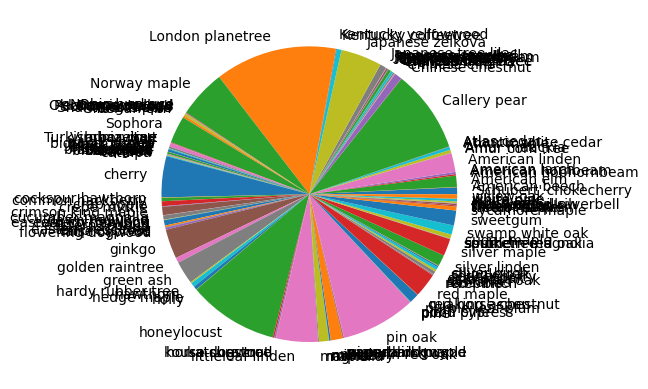

In [48]:
tree2015.groupby('spc_common').size().plot(kind = 'pie')


In [49]:
# find the top 10 dominant species 
treecount2015 = tree2015.groupby('spc_common').size()
treecount2015_sorted = treecount2015.sort_values(ascending=False)
treecount2015_sorted[0:10]

spc_common
London planetree     87014
honeylocust          64264
Callery pear         58931
pin oak              53185
Norway maple         34189
littleleaf linden    29742
cherry               29279
Japanese zelkova     29258
ginkgo               21024
Sophora              19338
dtype: int64

<Axes: title={'center': 'Top 10 Dominant Species in 2015'}>

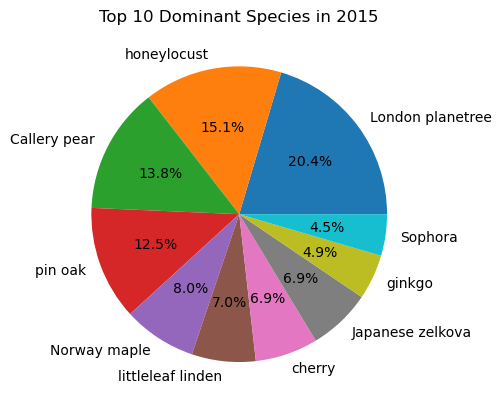

In [50]:
# pie chart for top ten dominant species 
treecount2015_sorted[0:10].plot.pie(autopct='%1.1f%%', title ='Top 10 Dominant Species in 2015')

### Line Graphs<a id=3.1.3></a>

<Axes: >

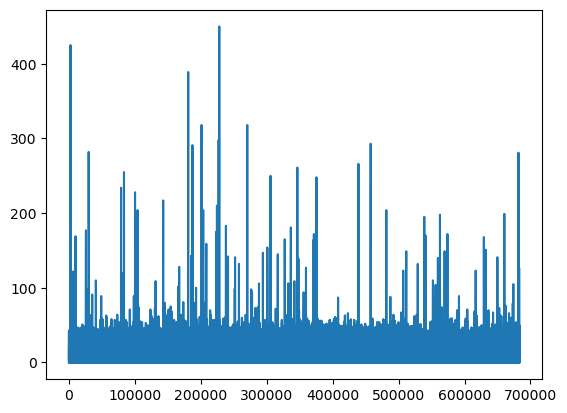

In [51]:
tree2015['tree_dbh'].plot()

### Numerical Variables <a id=3.2></a>

### Histogram <a id=3.2.1></a>
Pandas has multiple ways to do historgrams
1. pd.DataFrame.hist(column='your_data_column')
2. pd.DataFrame.plot(kind='hist')
3. pd.DataFrame.plot.hist()

array([[<Axes: title={'center': 'tree_dbh'}>]], dtype=object)

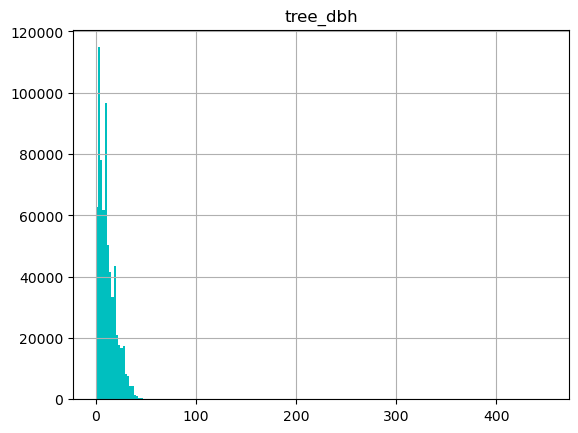

In [52]:
#tree2015.hist(column='tree_dbh', bins=200)
tree2015.hist('tree_dbh', bins=200,facecolor='c')

<Axes: ylabel='Frequency'>

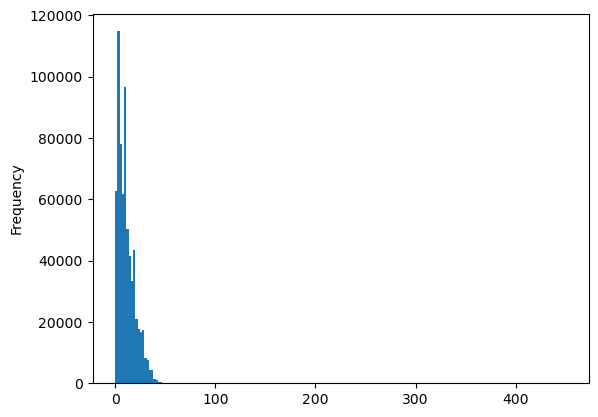

In [53]:
tree2015['tree_dbh'].plot(kind='hist', bins=200)
#tree2015.plot(kind='hist, column='tree_dbh', bins=200)

<Axes: ylabel='Frequency'>

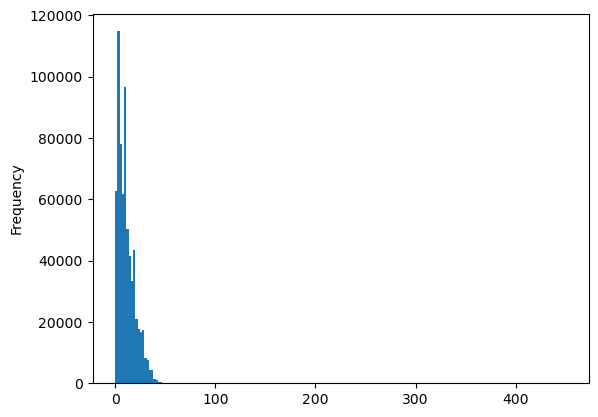

In [18]:
tree2015['tree_dbh'].plot.hist(bins=200)

In [ ]:
tree2015.plot.hist(bins=200)

<Axes: ylabel='Frequency'>

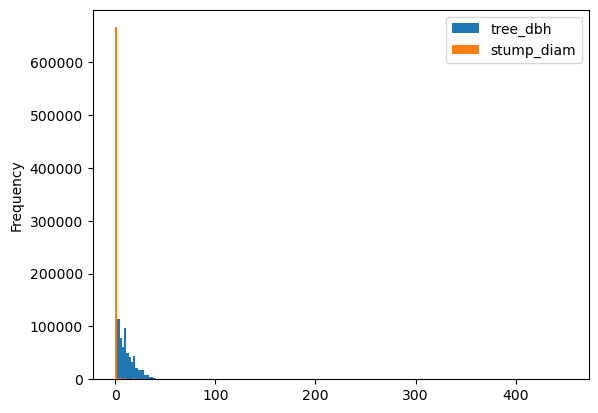

In [54]:
tree2015_dbh = tree2015[['tree_dbh','stump_diam']]
tree2015_dbh.plot.hist(bins=200)

In [ ]:
#tree2015.groupby(['spc_common'], sort=False).hist(column='tree_dbh', bins=200, figsize=(5,2)) 

array([[<Axes: title={'center': "'Schubert' chokecherry"}>,
        <Axes: title={'center': 'American beech'}>,
        <Axes: title={'center': 'American elm'}>,
        <Axes: title={'center': 'American hophornbeam'}>,
        <Axes: title={'center': 'American hornbeam'}>,
        <Axes: title={'center': 'American larch'}>,
        <Axes: title={'center': 'American linden'}>,
        <Axes: title={'center': 'Amur cork tree'}>,
        <Axes: title={'center': 'Amur maackia'}>,
        <Axes: title={'center': 'Amur maple'}>,
        <Axes: title={'center': 'Atlantic white cedar'}>],
       [<Axes: title={'center': 'Atlas cedar'}>,
        <Axes: title={'center': 'Callery pear'}>,
        <Axes: title={'center': 'Chinese chestnut'}>,
        <Axes: title={'center': 'Chinese elm'}>,
        <Axes: title={'center': 'Chinese fringetree'}>,
        <Axes: title={'center': 'Chinese tree lilac'}>,
        <Axes: title={'center': 'Cornelian cherry'}>,
        <Axes: title={'center': 'Douglas-fi

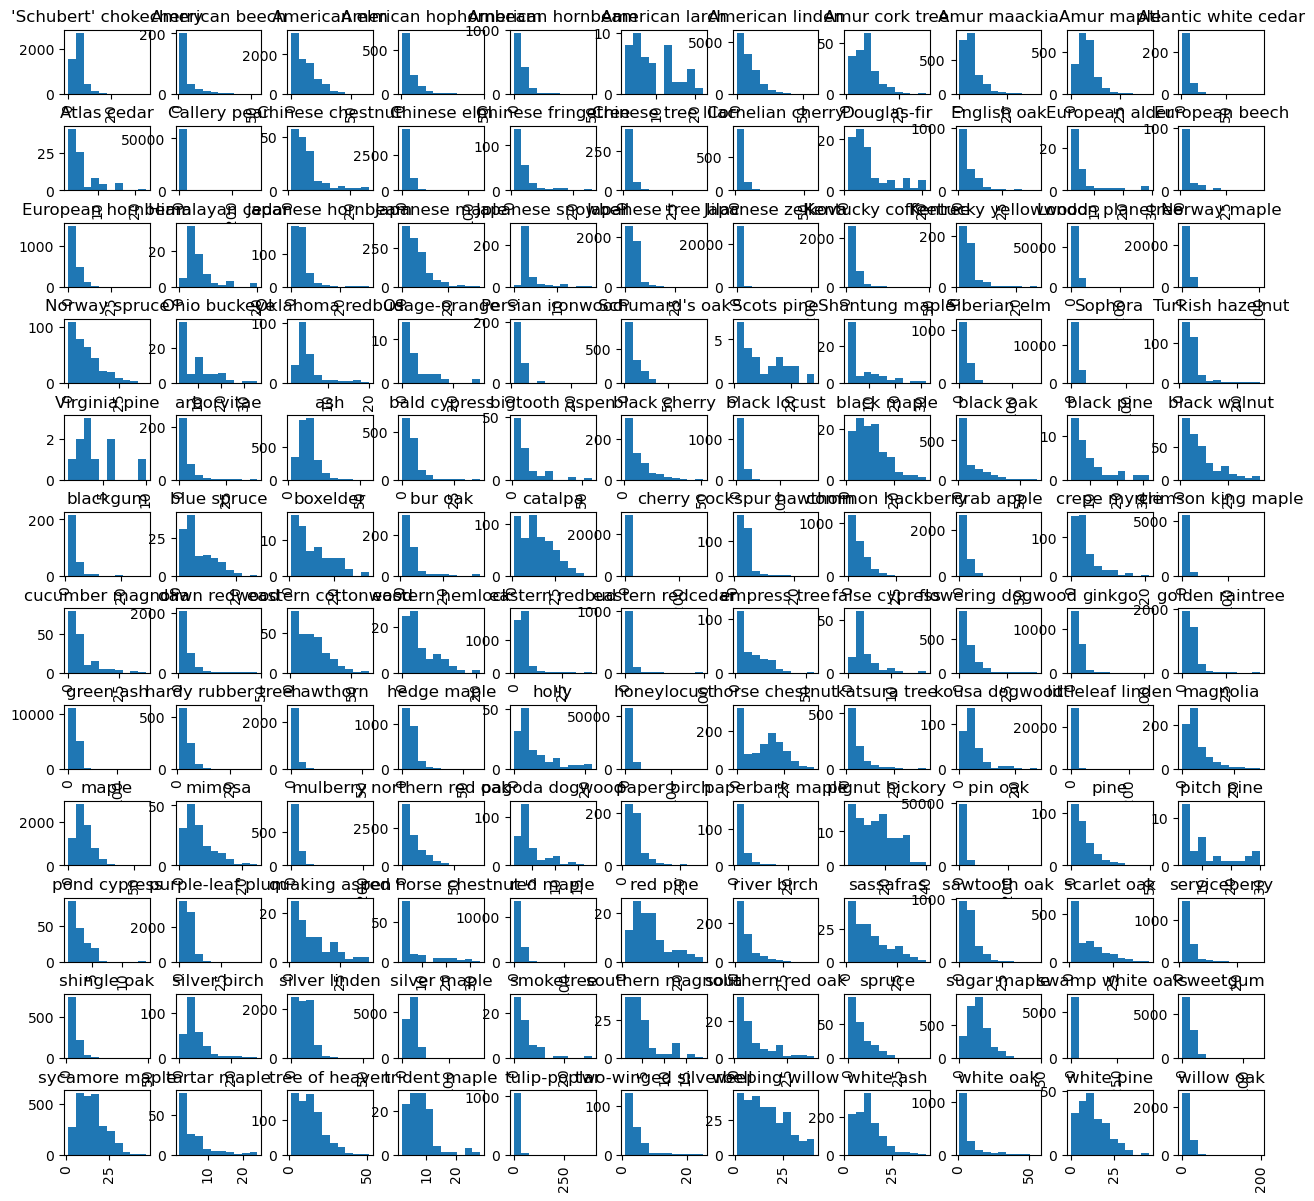

In [55]:
tree2015['tree_dbh'].hist(by=tree2015['spc_common'], figsize=(15,15))

### Density Plots <a id=3.2.2></a>

## Two-or-more-variables-visualization

### Categorical Variables <a id=3.1></a>

There are many visualization options for multiple categorical variables such as: **side by side graphs, grouped bar graphs, stacked bar graphs, mosaic plots, tree maps,** and **parallel sets**. 

### Numerical Variables 
see the air quality notebooks

### Time Series 

### Scatter plots 